# Project 01: Macro-Panel Data Literacy & Mediation Analysis
**Replicating the Core Pipeline of My Co-Authored Empirical Study in Python**

## 1. Project Objective
This project rebuilds the core analytical pipeline of a published empirical study (which I participated in as a 2nd author) to validate the methodology. 

**Crucially, while the original research relied on traditional GUI-based statistical software (SPSS), this project completely replicates and automates the mediation analysis using Python.** This transition demonstrates programmatic data literacy, reproducibility, and modern statistical modeling capabilities.

The analysis examines how parents' childhood economic adversity affects their children's academic achievement.

**Hypothesis:** Parents' childhood economic adversity ($X$) decreases perceived positive parenting ($M$), which ultimately mediates and leads to lower academic achievement of the child ($Y$).

## 2. Technical Stack
* **Data Manipulation:** `pandas`, `numpy`
* **Statistical Modeling:** `statsmodels`, `scipy` (OLS Regression based on Hayes' PROCESS macro approach)
* **Visualization:** `seaborn`, `matplotlib`

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Visualization Settings
sns.set_theme(style="whitegrid")
plt.rcParams['axes.unicode_minus'] = False

# 2. Synthetic Data Generation (N=5000)
# Simulating the statistical properties of the KOWEPS large-scale panel data to validate the analysis pipeline.
np.random.seed(42)
n_samples = 5000

# X: Childhood Economic Adversity
parent_adversity = np.random.normal(50, 15, n_samples)

# M: Positive Parenting (Negatively affected by X)
positive_parenting = 100 - (0.4 * parent_adversity) + np.random.normal(0, 10, n_samples)

# Y: Academic Achievement (Positively affected by M, Negatively affected by X)
academic_achievement = 20 + (0.6 * positive_parenting) - (0.1 * parent_adversity) + np.random.normal(0, 12, n_samples)

# Control Variables: Household Income & Child Age
income = np.random.normal(400, 150, n_samples)
age = np.random.randint(13, 19, n_samples)

# Create DataFrame
df_koweps = pd.DataFrame({
    'Parent_Adversity_X': parent_adversity,
    'Positive_Parenting_M': positive_parenting,
    'Academic_Achievement_Y': academic_achievement,
    'Household_Income': income,
    'Child_Age': age
})

# Inject 5% Missing Completely at Random (MCAR) to simulate real-world survey limitations
for col in df_koweps.columns:
    df_koweps.loc[df_koweps.sample(frac=0.05).index, col] = np.nan

print(f"Initial Raw Data Shape: {df_koweps.shape}")
print(df_koweps.isnull().sum())

Initial Raw Data Shape: (5000, 5)
Parent_Adversity_X        250
Positive_Parenting_M      250
Academic_Achievement_Y    250
Household_Income          250
Child_Age                 250
dtype: int64


## 3. Data Preprocessing & EDA
Handling missing values and outliers is crucial in macro-panel data. To preserve statistical power, this pipeline uses Median Imputation instead of listwise deletion, followed by Z-score based outlier trimming.

Cleaned Data Shape: (4930, 5)


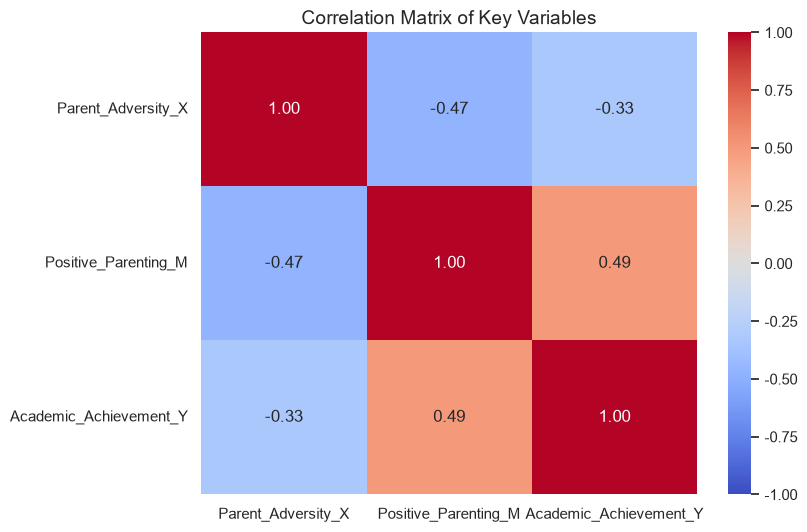

In [2]:
# 1. Missing Value Imputation (Median)
df_clean = df_koweps.fillna(df_koweps.median())

# 2. Outlier Control (Z-score trimming at 1% / 99%)
from scipy import stats
z_scores = np.abs(stats.zscore(df_clean))
df_clean = df_clean[(z_scores < 3).all(axis=1)]

print(f"Cleaned Data Shape: {df_clean.shape}")

# 3. Exploratory Data Analysis (EDA): Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df_clean[['Parent_Adversity_X', 'Positive_Parenting_M', 'Academic_Achievement_Y']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix of Key Variables", fontsize=14)
plt.show()

## 4. Mediation Analysis
Applying Baron & Kenny's steps and the concept of Hayes' PROCESS macro to test the mediating effect of Positive Parenting ($M$) using OLS Regression.

* **Step 1:** $X \rightarrow Y$ (Total Effect)
* **Step 2:** $X \rightarrow M$ (Path a)
* **Step 3:** $X, M \rightarrow Y$ (Direct Effect and Path b)

In [3]:
# Define Variables
X = df_clean['Parent_Adversity_X']
M = df_clean['Positive_Parenting_M']
Y = df_clean['Academic_Achievement_Y']
C = df_clean[['Household_Income', 'Child_Age']] # Controls

# [Step 2] Path a (X -> M)
X_M = sm.add_constant(pd.concat([X, C], axis=1))
model_a = sm.OLS(M, X_M).fit()

# [Step 3] Path b & c' (X, M -> Y)
X_M_Y = sm.add_constant(pd.concat([X, M, C], axis=1))
model_steps = sm.OLS(Y, X_M_Y).fit()

# Result Summary Output
print("==================================================")
print("[Step 2] Path a (X -> M) Summary")
print(f"Coefficient: {model_a.params['Parent_Adversity_X']:.4f}, p-value: {model_a.pvalues['Parent_Adversity_X']:.4f}")
print("--------------------------------------------------")
print("[Step 3] Path b & c' (X, M -> Y) Summary")
print(f"M -> Y Coefficient: {model_steps.params['Positive_Parenting_M']:.4f}, p-value: {model_steps.pvalues['Positive_Parenting_M']:.4f}")
print(f"X -> Y (Direct Effect): {model_steps.params['Parent_Adversity_X']:.4f}, p-value: {model_steps.pvalues['Parent_Adversity_X']:.4f}")
print("==================================================")

[Step 2] Path a (X -> M) Summary
Coefficient: -0.3698, p-value: 0.0000
--------------------------------------------------
[Step 3] Path b & c' (X, M -> Y) Summary
M -> Y Coefficient: 0.5321, p-value: 0.0000
X -> Y (Direct Effect): -0.1165, p-value: 0.0000
